# Lab 3: Pretraining a GPT model

This lab is about pretraining large language models. You will work through the full pretraining process for a GPT model, explore different settings, and implement optimisations that make training more efficient. You will also reflect on the impact of data curation on the quality of the pretrained model. By the end of the lab, you will have a solid understanding of how large language models are trained from scratch.

*Tasks you can choose for the oral exam are marked with the graduation cap 🎓 emoji.*

## Part 1: Pretraining pipeline

The GPT pretraining pipeline builds on the basic training loop for neural language models you have seen before, but includes several enhancements that improve stability and efficiency when training large models:

* It uses the [AdamW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) optimiser with weight decay instead of vanilla stochastic gradient descent.
* It implements a cosine decay learning rate schedule with a linear warmup phase.
* It accumulates gradient updates across multiple batches to allow training with larger effective batch sizes.
* It uses gradient clipping to prevent exploding gradients.

### Training configuration

We begin by setting up a configuration object that defines the key parameters of the training process. The original 124M-parameter GPT-2 model was trained on WebText, a private dataset with 300B tokens of Internet data. Our training pipeline is configured to train a Chinchilla-optimal version of the same model using the [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) dataset and a single A100 GPU with 80GB of memory.

In [2]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gpt2 import Config, Model

In [20]:
@dataclass
class TrainingConfig:
    device: torch.device = torch.device("cuda")
    shard_dir: str = "data"  # This is where the data is stored; a shard is a slice of a string

    # Training steps and data processing
    # Total tokens trained on is n_steps * n_tokens_per_step
    n_steps: int = 4768  # The number of steps for which the training will run, aka epochs
    n_tokens_per_step: int = 524288  # The number of tokens per step
    batch_size: int = 4  # The number of samples used to compute each gradient step
    sequence_len: int = 1024  # The total number of tokens possible to process at a time, aka "context"
    n_vocab: int = 50304  # The vocabulary size

    # Optimisation and learning rate scheduling
    weight_decay: float = 0.1  # Regularization parameter to make unused weights atrophy
    max_lr: float = 6e-4  # Maximum learning rate, used after warmup phase
    min_lr: float = 6e-5  # Minimum learning rate, used at start
    n_warmup_steps: int = 715  # Steps to do a linear warmup
    n_decay_steps: int = 4053  # Steps to perform the cosine decay
    betas: tuple[float, float] = (0.9, 0.95)  # Decay parameters for the gradients optimization in AdamW
    clip_norm: float = 1.0  # The norm of the gradient when clipped

#### 🎓 Task 3.01: Explaining the training parameters

Your first task is to explain the purpose of the training parameters. Some of them will already be known to you from the lectures, while others will become clear first as you progress through the lab and see how everything fits together. Because of this, it is best to revisit and complete this task towards the end of the lab when you have a full understanding of the training process.

One parameter to note is the vocabulary size (`n_vocab`). The GPT-2 tokeniser has a default vocabulary size of 50,257, but for training on a GPU, it is helpful to use numbers that are more hardware-friendly. Specifically, numbers with many factors of&nbsp;2 can lead to more efficient computation. To achieve this, we set the vocabulary size to 50,304, which is slightly larger than needed but has many factors of&nbsp;2. Note that the extra tokens will not be used in practice — they simply act as placeholders without meaningful embeddings.

NOTE: When preparing for the oral exam.
- Add notes on the parameters
- You can add material to this portfolio which can be used later  on

### Model

Next, we set up the GPT model. Our goal is to match the original training setup of GPT-2 as closely as possible. To do this, we follow the initialisation strategy outlined in the key research papers about GPT ([Radford et al., 2018](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf); [Radford et al., 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf); [Brown et al., 2020](https://arxiv.org/pdf/2005.14165)) as well as the official implementation ([link](https://github.com/openai/gpt-2)). Here is a summary of this strategy:

* Token embeddings → Normal distribution with mean $0$ and variance $0.02$.
* Position embeddings → Normal distribution with mean $0$ and variance $0.01$.
* Weights of the linear layers → Normal distribution with mean $0$ and variance $0.02$.
* Biases of the linear layers → Initialised to zeros.
* Weight sharing between the final linear layer and the token embedding.

#### 🎈 Task 3.02: Initialising the model

Expand the skeleton code below to create a fresh model and initialise it according to the GPT-2 strategy.

In [21]:
from jinja2.nodes import Mod
from typing import Dict
import math
def get_uniform_params(mean: float, var: float) -> Dict[str, float]:
    b = math.sqrt(3.0) * var
    a = mean - b
    return {"a": a, "b": b}

def configure_model(config: TrainingConfig) -> Model:
    config = Config()
    model = Model(config)
    small_var = get_uniform_params(0.0, 0.01)
    larger_var = get_uniform_params(0.0, 0.02)
    nn.init.uniform_(model.wte.weight,**larger_var)
    nn.init.uniform_(model.wpe.weight, **small_var)
    for block in model.h:
        nn.init.uniform_(block.attn.c_attn.weight,**larger_var)  
        nn.init.uniform_(block.attn.c_proj.weight, **larger_var)
        nn.init.uniform_(block.mlp.c_fc.weight, **larger_var)
        nn.init.uniform_(block.mlp.c_proj.weight, **larger_var)
        block.mlp.c_proj.weight.data *= 2 * config.n_layer ** -0.5

        nn.init.zeros_(block.mlp.c_fc.bias)
        nn.init.zeros_(block.attn.c_proj.bias)
        nn.init.zeros_(block.mlp.c_proj.bias)
        nn.init.zeros_(block.attn.c_attn.bias)

    # Use weights of embeddings for output layer
    model.lm_head = model.wte.weight

    return Model(Config(n_vocab=config.n_vocab))

#### Scaled residual initialisation

There is one important detail in the GPT-2 initialisation strategy that we have not addressed yet. [Radford et al. (2019)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) write (Section&nbsp;2.3):

> A modified initialization which accounts for the accumulation on the residual path with model depth is used. We scale the weights of residual layers at initialization by a factor of $1/\sqrt{N}$ where $N$ is the number of residual layers.

Why is this necessary? One of the challenges in training large language models is controlling the variance of activations. However, there are two points in the GPT architecture where variance can grow uncontrollably: the residual connections after the multi-head attention and the MLP. Since these connections simply add activations from previous layers, their variances increases with depth. To see this, note that if we sum $N$ independent normally distributed variables with variance $\sigma^2$, the result has variance $N \sigma^2$. The factor $1/\sqrt{N}$ compensates for this growth.

#### 🎓 Task 3.03: Implementing the scaled residual initialisation

**Step&nbsp;1.** Suppose each summand in a sum of $N$ independent normally distributed variables with variance $\sigma^2$ is scaled by a factor of&nbsp;$k$. The total variance then becomes $N k^2 \sigma^2$. What happens to the total variance if we choose $k = 1/\sqrt{N}$, as in GPT-2?

$$
N (1/\sqrt{N})^2 \sigma^2 = \frac{N}{N} \sigma^2 = \sigma^2
$$

**Step&nbsp;2.** Test the mathematical theory with a simulation. Generate normally distributed activations using `torch.randn()`. Sum the activations across $N$ hypothetical residual layers, first without scaling and then with the $1/\sqrt{N}$ adjustment. Compare the two cases by producing a plot showing the variance at each layer. To compute the variance of a tensor, use `torch.var()`.


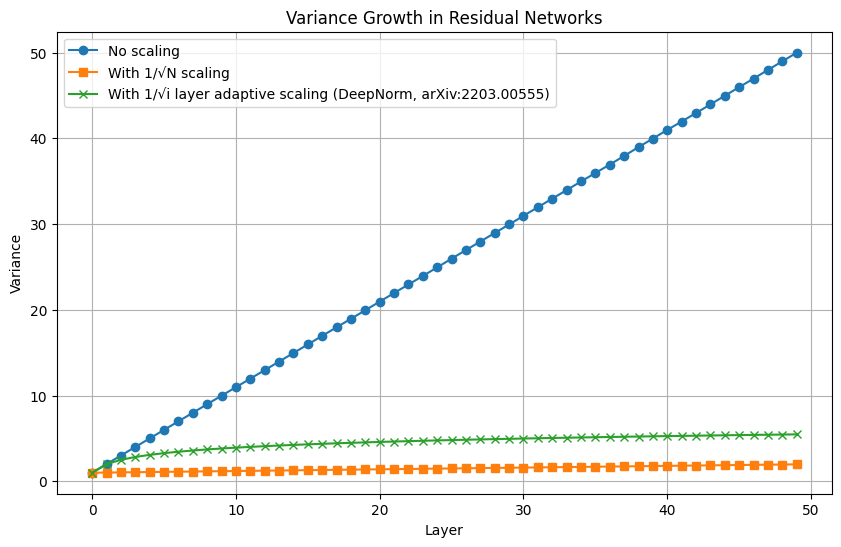

In [22]:
# generated with claude, commented by me
import torch
import matplotlib.pyplot as plt

N = 50  # number of simulated layers
d_model = 512  # embedding dimension
batch_size = 32
seq_len = 128

x_no_scale = torch.randn(batch_size, seq_len, d_model)
x_with_scale = x_no_scale.clone()
x_adaptive_scale = x_no_scale.clone()

variances_no_scale = [torch.var(x_no_scale).item()]
variances_with_scale = [torch.var(x_with_scale).item()]
variances_adaptive_scale = [torch.var(x_adaptive_scale).item()]


for i in range(1, N):
    # Simulate layer output (assume random) 
    layer_output = torch.randn(batch_size, seq_len, d_model) 
    
    # Perform the simulated residual connection (Without scaling)
    x_no_scale = x_no_scale + layer_output # 
    variances_no_scale.append(torch.var(x_no_scale).item())
    
    # Perform the simulated residual connection (With 1/√N scaling)
    x_with_scale = x_with_scale + layer_output / (N ** 0.5) 
    variances_with_scale.append(torch.var(x_with_scale).item())

    # Perform the simulated residual connection (With 1/√i  adaptive scaling)
    x_adaptive_scale = x_adaptive_scale + layer_output / (i ** 0.5) 
    variances_adaptive_scale.append(torch.var(x_adaptive_scale).item())

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(N), variances_no_scale, label='No scaling', marker='o')
plt.plot(range(N), variances_with_scale, label='With 1/√N scaling', marker='s')
plt.plot(range(N), variances_adaptive_scale, label='With 1/√i layer adaptive scaling (DeepNorm, arXiv:2203.00555)', marker='x')
plt.xlabel('Layer')
plt.ylabel('Variance')
plt.title('Variance Growth in Residual Networks')
plt.legend()
plt.grid(True)
plt.show()

#### 3.03 ADAPTIVE SCALING


- $k_l=1 / N - l + 1, l \in [1, N]^1$ DeepNet used the adaptive re-rescaling strategy of the initialization to achieve very deep networks[2022, DeepNet: Scaling Transformers to 1,000 Layers, arxiv:2203.00555](https://arxiv.org/html/2505.09343v1)
- This very recent paper (accepted to Neurips2025) discusses adaptive re-scaling of the outputs of the LayerNorm by their layer number $1/\sqrt{l}$
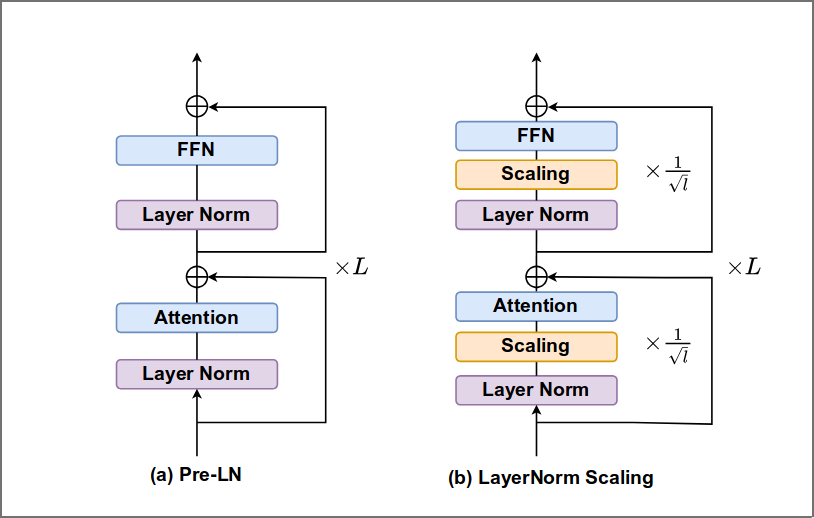


**Step&nbsp;3.** Update your model initialisation from the previous task to include the scaled residual initialisation. The adjustment should only be applied to the linear layer at the end of the multi-head attention and MLP blocks (`c_proj`). Note that a GPT model with $L$&nbsp;layers has $N = 2 L$ residual layers, because there are two residual connections in each layer (after the multi-head attention and the MLP).

### Data

As mentioned before, GPT-2 was pretrained on a 300B non-public dataset collected by OpenAI. Our pretraining data comes from the public [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) dataset. The full dataset contains 1.3&nbsp;trillion tokens, but here, we will only work with a small sample. We have preprocessed the data by tokenising it with the GPT-2 tokeniser and storing the token indices in equal-sized NumPy arrays, which we call **shards**. The function below loads these shards from a given directory and yields them as PyTorch tensors.

In [23]:
from typing import List
def shards(shard_dir: str) -> List[torch.Tensor]:
    for shard in sorted(os.listdir(shard_dir)):
        if shard.endswith(".npy"):
            yield torch.from_numpy(np.load(os.path.join(shard_dir, shard), allow_pickle=True).astype(np.int64))

In total, our training data consists of 300M tokens:

In [7]:
sum(s.numel() for s in shards(TrainingConfig().shard_dir))

0

#### 🎓 Task 3.04: Batching the data

Implement a function `make_batches()` that packages the token indices in the shards into pairs of input and output batches suitable for language modelling training. One efficient way to do this is sketched in the cell below:

In [8]:
shard = torch.tensor(range(15), dtype=torch.long)

# Suppose we want to package the tokens in this shard into batches of shape (2, 3).

# Step 1: Segment the shard into overlapping chunks of size 2 * 3 + 1
chunk1 = shard[0:7]
chunk2 = shard[6:13]
excess = shard[12:]

# Step 2: Create batches from all but the last and all but the first token in each chunk
x1, y1 = chunk1[:-1].view(2, 3), chunk1[1:].view(2, 3)
x2, y2 = chunk2[:-1].view(2, 3), chunk2[1:].view(2, 3)

The following code cell shows the signature of `make_batches()`.

In [9]:
def make_batches(config: TrainingConfig):
    chunk_size = config.batch_size * config.sequence_len + 1
    carry_over = torch.Tensor()
    for shard in shards(config.shard_dir):
        if len(carry_over):
            shard = torch.cat([carry_over, shard], dim=0)
            carry_over = torch.Tensor()
        for i in range(0, len(shard) - chunk_size + 1, chunk_size):
            chunk = shard[i : i + chunk_size]
            x = chunk[:-1].view(config.batch_size, config.sequence_len)
            y = chunk[1:].view(config.batch_size, config.sequence_len)
            yield x, y
        n_full_chunks =  (len(shard) - chunk_size) // chunk_size + 1
        carry_over = shard[chunk_size*n_full_chunks:]
        

**Hints and considerations:**

* Batches can stretch across shards. You will have to carry over excess tokens at the end of shards to the next batch.
* All batches should have the same shape. Drop excess tokens at the end of the last shard.
* The correct number of batches of shape $(64, 1024)$ for the training shards is $4577$.

In [10]:
batches = make_batches(TrainingConfig())
print(len(list(batches)))

0


### Optimiser

The code in the cell below configures the [AdamW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) optimiser. It uses weight decay on all parameters with two or more dimensions (e.g., weights in linear layers), and no decay on the remaining parameters. If the model is on a CUDA device, the code uses the “fused” implementation of the optimiser for efficiency.

In [11]:
def configure_optimizer(model: Model, config: TrainingConfig):
    params = [p for p in model.parameters() if p.requires_grad]
    decay_params = [p for p in params if p.dim() >= 2]
    no_decay_params = [p for p in params if p.dim() < 2]
    param_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(
        param_groups,
        lr=config.max_lr,
        betas=config.betas,
        fused=(config.device.type == "cuda"),
    )

#### 🎓 Task 3.05: Exploring the beta parameters

The AdamW optimiser is controlled by two hyperparameters $\beta_1$ and $\beta_2$:

* $\beta_1$ controls the moving average of past gradients.
* $\beta_2$ controls the moving average of past squared gradients, which affects the adaptive learning rate scaling.

Lower values correspond to reduced effect of the respective average, that is, less smoothing and faster adaptation to recent values. In this task, you will explore how different beta values affect the convergence behaviour of the optimiser.

The code below applies the optimiser to the function $f(x) = (x-2)^2 + (y+3)^2$, which has a global minimum at $(2, -3)$. The code yields the trajectories of the parameter values $(x, y)$ visited by Adam when started at $(-4, 5)$ for different values of&nbsp;$\beta_1$ and $\beta_2$.

In [12]:
def adam_trajectories(betas):
    def loss_function(x, y):
        return (x - 2) ** 2 + (y + 3) ** 2

    for beta1, beta2 in betas:
        x = torch.tensor([-4.0], requires_grad=True)
        y = torch.tensor([5.0], requires_grad=True)
        optimizer = torch.optim.AdamW((x, y), lr=0.125, betas=(beta1, beta2))
        trajectory = []
        for _ in range(100):
            optimizer.zero_grad()
            loss = loss_function(x, y)
            loss.backward()
            optimizer.step()
            trajectory.append((x.item(), y.item()))
        yield trajectory, f"β₁ = {beta1}, β₂ = {beta2}"

 Your task is to visualise different trajectories in a plot and analyse the results. Proceed as follows:

* Start by plotting the trajectory for the default values for $\beta_1$ and $\beta_2$. (Consult the PyTorch documentation to find these.)
* Add the plot for the beta values used in our training configuration. For this simple example, do you see a significant difference?
* Add more plots to see what happens if the beta values are too high or too low.

Default Betas (0.9, 0.999): (x,y)* = 2.01, -2.67
Current Betas Config: (x,y)* = 1.92, -3.14
Low Betas (0.5, 0.555): (x,y)* = 2.01, -3.01
High Betas (0.99999, 0.9999999): (x,y)* = 5.10, -5.84


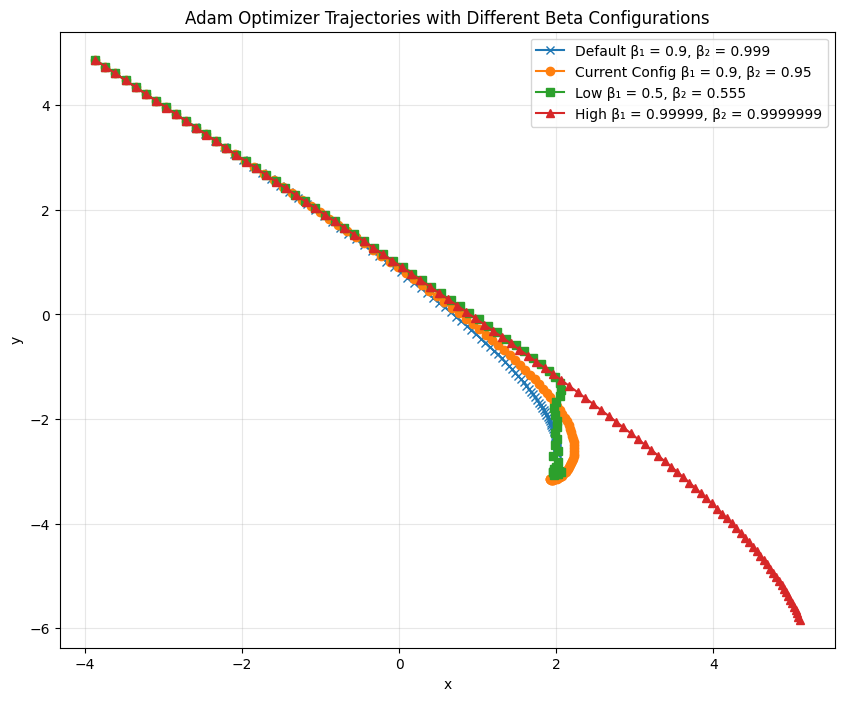

In [13]:
# Plot all trajectories in one plot
plt.figure(figsize=(10, 8))

# Default betas (0.9, 0.999)
for trajectory, label in adam_trajectories([(0.9, 0.999)]):
    plt.plot(*zip(*trajectory), label=f"Default {label}", marker="x")
    x, y = trajectory[-1]
    print(f"Default Betas (0.9, 0.999): (x,y)* = {x:.2f}, {y:.2f}")

# Current Betas Config
for trajectory, label in adam_trajectories([TrainingConfig().betas]):
    plt.plot(*zip(*trajectory), label=f"Current Config {label}", marker="o")
    x, y = trajectory[-1]
    print(f"Current Betas Config: (x,y)* = {x:.2f}, {y:.2f}")

# Low Betas
for trajectory, label in adam_trajectories([(0.5, 0.555)]):
    plt.plot(*zip(*trajectory), label=f"Low {label}", marker="s")
    x, y = trajectory[-1]
    print(f"Low Betas (0.5, 0.555): (x,y)* = {x:.2f}, {y:.2f}")

# High Betas
for trajectory, label in adam_trajectories([(0.99999, 0.9999999)]):
    plt.plot(*zip(*trajectory), label=f"High {label}", marker="^")
    x, y = trajectory[-1]
    print(f"High Betas (0.99999, 0.9999999): (x,y)* = {x:.2f}, {y:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Adam Optimizer Trajectories with Different Beta Configurations")
plt.grid(True, alpha=0.3)
plt.show()

#### ADAM AND MOMENTUM

Having read more about these parameters and learned about their origins, these parameters can be interpreted in two ways. We can, for our intuition's sake, interpret these parameters as momentum.

- Red line (high $\beta_1,\beta_2$) overshoots the target (2,-3) since it "remembers" too much of its' original trajectory along the loss surface
- Green line has very slow momentum, and it looks like it "drops" into the optimum.
- Orange and blue line similarly, seem to best adapt to moving closer to the optimum, since their trajectories start to bend towards it earlier.

### Learning rate scheduling

Your next task is to implement the learning rate scheduler. As mentioned before, GPT-2 is trained with cosine decay from a maximum to a minimum learning rate in conjunction with a linear warmup phase.

#### 🎓 Task 3.06: Implementing cosine decay

Implement a function `get_lr_factor()` that determines the learning for a given `step`. To work with the rest of the implementation, this function should return its result as a factor of the maximum learning rate. In particular, the result at the end of the linear warmup should be&nbsp;$1$. Validate your implementation by plotting the function against the training steps.

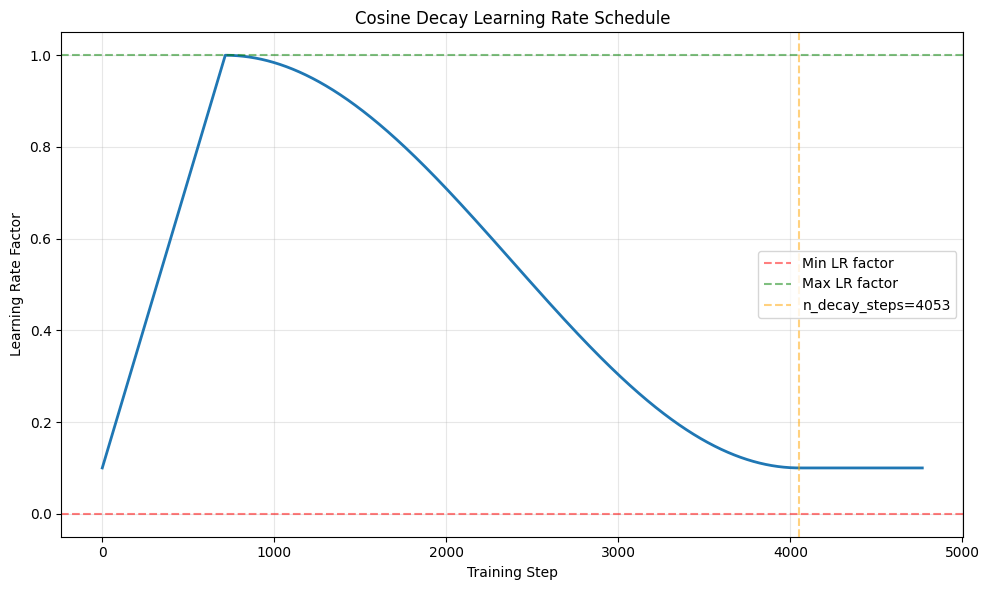

In [28]:
def get_lr_factor(step: int, config: TrainingConfig) -> float:
    pi = math.pi
    min_factor = config.min_lr / config.max_lr  # This is where we should end up

    if step < config.n_warmup_steps:
        # Warmup: min_lr → max_lr
        return min_factor + (1 - min_factor) * step / config.n_warmup_steps
    elif step < config.n_decay_steps:
        # Decay: max_lr → min_lr (starts immediately after warmup)
        decay_progress = (step - config.n_warmup_steps) / (config.n_decay_steps - config.n_warmup_steps)
        cosine_factor = 0.5 * (1 + math.cos(pi * decay_progress))
        return min_factor + (1 - min_factor) * cosine_factor
    else:
        # Stay at min_lr
        return min_factor

_config = TrainingConfig()
steps = np.arange(0, _config.n_steps)
lr_factors = [get_lr_factor(step, _config) for step in steps]

plt.figure(figsize=(10, 6))
plt.plot(steps, lr_factors, linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate Factor')
plt.title('Cosine Decay Learning Rate Schedule')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Min LR factor')
plt.axhline(y=1, color='g', linestyle='--', alpha=0.5, label='Max LR factor')
plt.axvline(x=_config.n_decay_steps, color='orange', linestyle='--', alpha=0.5, label=f'n_decay_steps={_config.n_decay_steps}')
plt.legend()
plt.tight_layout()
plt.show()

**Hint:** For $x \in [0, 1]$, the relevant cosine decay is described by the term $\frac{1}{2} \cdot (1 + \text{cos}(\pi x))$.

#### N DECAY STEPS

- I struggled a bit with this one. Think I got it right now. Especially since the function is named "get_lr_factor" we need to compute the final factor using the min and max learning rates.

### Training loop

At this point, we have everything in place to put together a first version of the training loop. Here it is:

In [29]:
from tqdm.notebook import tqdm_notebook as tqdm
torch.set_float32_matmul_precision("high")

def train(config: TrainingConfig):
    model = configure_model(config)
    model = model.to(config.device)
    model = torch.compile(model)
    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda lr: get_lr_factor(lr, config),
    )
    n_micro_steps = config.n_tokens_per_step // (
        config.batch_size * config.sequence_len
    )
    tqdm_range = tqdm(range(config.n_steps))
    for step in tqdm_range:
        t1 = time.time()
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)
            with torch.autocast(device_type="cuda"):
                logits = model(x)
                loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            (loss / n_micro_steps).backward()
            running_loss += loss.item()
        running_loss /= n_micro_steps
        nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
        optimizer.step()
        lr = scheduler.get_last_lr()[0]
        scheduler.step()
        torch.cuda.synchronize()
        t2 = time.time()
        delta = t2 - t1
        tokens_per_second = (config.n_tokens_per_step) / delta
        
        tqdm_range.set_postfix(
            loss=f"{running_loss:.4f}",
            lr=f"{lr:.4e}",
            tps=f"{tokens_per_second:.2f}",
        )


Most of the steps should look familiar from previous labs or earlier tasks in this notebook. However, a few key aspects will be new:

**Moving the model and data to the training device.** The model and each batch are moved to the training device using `.to()`. In our training configuration, `config.device` is an NVIDIA GPU, which supports fast tensor computations.

**Gradient accumulation.** Instead of taking an optimisation step after every batch, we accumulate gradients over multiple batches (“micro-steps”). Each batch contributes to the gradients using `loss.backward()`.

**Gradient clipping.** Before updating weights, the gradients are clipped using `clip_grad_norm_()`. This prevents excessively large updates that could destabilise training. The clipping threshold is set by `config.clip_norm`.

#### 🎓 Task 3.07: Fixing the training loop

Try to train a model by executing the code below:

In [18]:
!echo $TRITON_LDCONFIG_PATH

In [19]:
train(TrainingConfig())

  0%|          | 0/4768 [00:00<?, ?it/s]

StopIteration: 

You will run into two problems:

**Memory issues.** As mentioned above, the training has been set up for an A100 GPU with 80GB of memory. If you are using a less powerful GPU, you will see an out-of-memory error. To fix this, reduce the batch size to lower the memory load on the GPU. Start by halving the batch size and keep adjusting it until you find the largest batch size that fits on your GPU. (You may have to restart the Jupyter kernel to reset the GPU.)

**High losses.** The training losses start at very high values. Recall that the model’s goal is to predict the next token. At the start, the model’s weights are random, so we expect it to output a uniform distribution over the vocabulary. This means each token should have a probability of $1/V$, where $V$ is the vocabulary size. Given this, what should the initial loss be? Think about the cross-entropy loss for a uniform distribution.

(You will fix the problem with the high losses in the next task.)

- $x_{n,y_n}$ means: "the logit at position $n$ for the true token $y_n$"

The probability that the model assigns to the correct token $y_n$ is:

$$P(y = y_n) = \frac{\exp(x_{n,y_n})}{\sum_{i=1}^{V} \exp(x_{n,i})}$$

Since initialization is uniform random around 0 we have:

$$P(y = y_n) \approx \frac{\exp(0)}{\sum_{i=1}^{V} \exp(0)} = \frac{1}{V}$$

Thus, the loss for each prediction in our early model is:

$$
l_n = -\log P(y = y_n) = -\log \frac{1}{V} = \log{V} \approx 10.82
$$

#### 🎓 Task 3.08: Fixing the gradient accumulation

The gradient accumulation in the `train()` function is not implemented correctly. To see this, consider the following example. We set up a linear layer and pass in some random input of shape $[2, 3]$. First, we compute the loss and gradients in the normal way. Then, we do the same thing using gradient accumulation over two singleton batches, in the way this is implemented in `train()`. As you will see, the two outputs are different.

In [30]:
def accumulation_example(n:int = 5):
    # Set up a simple model and simulate some input
    model = nn.Linear(3, 2)
    x = torch.randn(n, 3)
    y = torch.randint(0, 2, (n,))

    # Compute the gradient on the complete input
    model.zero_grad()
    output = model(x)
    loss = F.cross_entropy(output, y)
    loss.backward()
    print(model.weight.grad)

    # Compute the gradient using micro-batches (flawed)
    model.zero_grad()
    for i in range(n):
        output = model(x[i : i + 1])
        loss = F.cross_entropy(output, y[i : i + 1], reduction="sum")
        (loss / n).backward()
    print(model.weight.grad)


accumulation_example(100)

tensor([[-0.0226, -0.0116,  0.1462],
        [ 0.0226,  0.0116, -0.1462]])
tensor([[-0.0226, -0.0116,  0.1462],
        [ 0.0226,  0.0116, -0.1462]])


Your task is to fix the flawed implementation of gradient accumulation in the training loop.

1. Propose a fix for the problem illustrated in the example.
2. Validate your proposal by modifying the example.
3. Once you are convinced that your fix is correct, apply it to the training loop.
4. How does the fix affect the loss?

## Part 2: Efficiency optimisations

Training large language models from scratch is a computationally intensive task. Efficient training not only speeds up model convergence but also reduces hardware costs and energy consumption. As models grow in size, optimising the training process becomes increasingly important to ensure that resources are used effectively. In the second part of this lab, we will look into a few such optimisation techniques.

#### 🎓 Task 3.09: Profiling the training loop

Before we explore optimisations, we first need a way to measure training speed. We will define training speed as the **number of tokens processed per second**. Your task is to implement this measurement in the training loop.

**Step&nbsp;1.** Keep track of the number of tokens processed in each optimisation step.

**Step&nbsp;2.** Add a timer to measure the time taken per step. For accurate results, call `torch.cuda.synchronize()` before stopping the timer. This ensures all GPU computations finish before recording the time.

Once you have added this measurement, train the model for a few steps and answer the following questions:

* Based on your measured training speed, how long would it take to train on all data (300M tokens)?
* How much data and time would be required to train a Chinchilla-optimal version of the model?

For 300M tokens:
- tokens / second  ≈ 9131.26
- training tokens = 300M
- total time: 300M / (9131.26 token / seconds) ≈ 32854 seconds ≈ 0.38 days

For chincilla-compute optimal (all steps)
- total tokens = 524,288 tokens / step × 4,768 steps ≈ 2.48B tokens
- tokens / second  ≈ 9131.26
- training tokens ≈ 20 × number of parameters = 124M  × 20 = 2.4B tokens
- total time to train: 2.48B tokens / (9131.26 token / seconds) ≈ 3.2 days



### Floating-point representations

One of the optimisations we can make when training large language models is choosing an appropriate floating-point representation. A floating-point number is represented using three components: a **sign bit**, an **exponent**, and a **fraction** (also called mantissa). The number of bits assigned to the exponent determines the *range* of the representation, while the number of bits in the fraction determines the *precision*.

The most commonly used floating-point format is single-precision floating point (fp32), which uses 1&nbsp;sign bit, 8&nbsp;exponent bits, and 23&nbsp;fraction bits. However, most deep learning computations do not require the full 23-bit precision of fp32. As a result, modern hardware supports lower-precision formats that improve performance and memory efficiency while maintaining training stability. We are particularly interested in two of those:

**TensorFloat-32 (tf32)** is a precision format introduced by NVIDIA. It keeps the same 8-bit exponent as fp32, preserving the same numerical range. However, tf32 reduces the fraction size to 10 bits, leading to lower precision but faster matrix multiplications on dedicated GPUs.

**Brain Floating Point 16 (bf16)** is another reduced precision format widely used in NVIDIA GPUs. Like tf32, bf16 has the same 8-bit exponent as fp32, and therefore, the same range. However, bf16 has only 7 bits for the fraction. Unlike tf32, which is primarily used for internal computations, bf16 can be directly stored and used for activations, weights, and gradients, which can save memory (16 bits per value instead of 32).

#### 🎈 Task 3.10: Exploring floating-point representations

Your task is to rewrite the training loop to take advantage of specialised floating-point representations.

**Step&nbsp;1.** By default, PyTorch uses the fp32 format for internal computations (“highest precision”). Read the documentation of [`torch.set_float32_matmul_precision()`](https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html) to find out how to change this default and use tf32 if possible.

**Step&nbsp;2.** Computing the forward pass and the loss requires even less precision than other parts of the training loop. Read the documentation of [`torch.autocast()`](https://pytorch.org/docs/stable/amp.html#torch.autocast) to find out how to execute these operations using the bf16 format.

**Step&nbsp;3.** Repeat your profiling experiments with the modified training loop. How much time would be required to train the model now that you have implemented the floating-point optimisations?

#### Answer 3.10

Using these steps I went from ~9000 tokens / second to 28403.80 tokens / second

### Just-in-time compilation

The second optimisation we will explore is **just-in-time (JIT) compilation** – a technique to speed up code by compiling it at runtime, rather than before execution. This allows the compiler to optimise the code dynamically based on actual inputs and hardware conditions.

PyTorch provides a function [`torch.compile()`](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html) that uses JIT compilation to automatically optimise deep learning models. Instead of executing PyTorch operations one by one, this function analyses the computation, restructures it, and generates highly efficient machine code. This optimised code can often be run as a single fused operation on the GPU.

The performance boost from JIT compilation is especially noticeable on high-end GPUs like the NVIDIA A100 or H100, but it can still provide smaller speedups on less powerful GPUs.

#### 🎈 Task 3.11: Exploring just-in-time compilation

In this task, you will measure how much `torch.compile()` improves the training speed of the GPT-2 model. To enable JIT compilation, add the following line to the training loop:

```
model = torch.compile(model)
```

Make sure to place this *after* moving the model to the training device so the optimisation can be tailored to the hardware you are using. Once you have enabled JIT compilation, rerun your profiling experiments and compare the training speed before and efter.

## Part 3: Evaluate the pre-trained model

This notebook contains all the code needed to train a GPT-2 model on the FineWeb-Edu dataset. However, training on the full dataset is not practical within the time and resource limits of this lab.

To save time, we provide a pretrained model that was trained using the exact same settings you developed earlier. The only difference is that we used a compute node with 8 NVIDIA A100 GPUs (80GB each). With this setup, a full Chinchilla-optimal training run takes about 30 minutes.

We provide the trained model in the file `gpt-2-fineweb-edu.pt`. You can load it with the following code:

In [17]:
pretrained = Model(Config(n_vocab=50304))
pretrained.load_state_dict(torch.load("gpt-2-fineweb-edu.pt"))
pretrained.lm_head.weight = pretrained.wte.weight

#### 🎓 Task 3.12: Evaluating the pretrained model

The next cell contains code for evaluating the FineWeb-Edu model on the same small sample from the [HellaSwag](https://rowanzellers.com/hellaswag/) benchmark you already used in lab&nbsp;2. How does its score compare to that of the original GPT-2 model? What does this result tell you about the impact of data quality on the downstream performance of language models?

Observation:

Performance on the original GPT2 was 30.47% accuracy and here we get 29.69% which is ~ 0.80% less performance with 1/4 of the tokenstrained. The original GPT2 with 124M parameters trained with 10 billion tokens and we trained with 2.5 billion tokens (chincilla optimal). From this result, we see that a chincilla-optimal model gives us a comparable model using less tokens from a better dataset. It could be that we get better performance on tasks that are closer to the distribution of educational content than on common-sense reasoning like Hellaswag.

In [18]:
import json

import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

with open("hellaswag-mini.jsonl") as f:
    n_correct = 0
    n_total = 0
    for line in f:
        sample = json.loads(line)
        prefix = tokenizer.encode(sample["ctx"])
        ending_scores = []
        for i, ending in enumerate(sample["endings"]):
            suffix = tokenizer.encode(" " + ending)
            context = torch.tensor([prefix + suffix], dtype=torch.long)
            with torch.no_grad():
                logits = pretrained(context)
                ending_score = torch.nn.functional.cross_entropy(
                    logits[0, -len(suffix) - 1 : -1], context[0, -len(suffix) :]
                )
            ending_scores.append((ending_score, i))
        predicted = min(ending_scores)[1]
        n_correct += int(predicted == sample["label"])
        n_total += 1
    print(f"Accuracy: {n_correct / n_total:.2%}")

Accuracy: 29.69%


**🥳 Congratulations on finishing lab&nbsp;3!**